<a href="https://colab.research.google.com/github/justamy20/midterm-machine-learning/blob/main/fraud_detection_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Machine Learning

**Nama:** Syeh Khatami
**NIM:** 101032300157
**Program Studi:** S1 Teknik Komputer
**Semester:** 6

---
*Notebook ini berisi end-to-end pipeline untuk mendeteksi penipuan transaksi menggunakan Machine Learning, lengkap dengan Optuna untuk hyperparameter tuning dan MLFlow untuk tracking.*

# 🔍 IEEE-CIS Fraud Detection — End-to-End Machine Learning Pipeline
**UTS Machine Learning — Individual Task**

**Pipeline Overview:**
1. Data Loading & EDA
2. Data Preprocessing & Feature Engineering
3. Model Training (Multiple Models)
4. Hyperparameter Tuning dengan **Optuna**
5. Evaluasi & Perbandingan Model
6. Experiment Tracking dengan **MLflow**

## 📦 1. Install & Import Libraries

In [3]:
# Install dependencies (jalankan sekali)
!pip install optuna mlflow xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 674.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [4]:
def reduce_mem_usage(df):
    """Fungsi untuk mengecilkan ukuran data di RAM"""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max: df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max: df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max: df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max: df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max: df[col] = df[col].astype(np.float32)
                else: df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memori berkurang dari {start_mem:.2f} MB menjadi {end_mem:.2f} MB')
    return df

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# Evaluation
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
    RocCurveDisplay
)

# Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Experiment Tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

print('✅ Semua library berhasil di-import!')

✅ Semua library berhasil di-import!


## 📂 2. Load Dataset

> **Catatan:** Dataset `train_transaction.csv` (~600MB) tidak di-upload ke GitHub karena terlalu besar.
> Download dari link yang tersedia di README.md, lalu letakkan di folder yang sama dengan notebook ini.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ============================================================
# GANTI PATH DI BAWAH SESUAI LOKASI FILE KAMU DI GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Menggunakan path fraud_dataset dari Google Drive kamu
TRANSACTION_PATH = '/content/drive/MyDrive/fraud_dataset/train_transaction.csv'
IDENTITY_PATH    = '/content/drive/MyDrive/fraud_dataset/train_identity.csv'

print('\nLoading train_transaction.csv ...')
# TIPS: Tambahkan parameter nrows=50000 di bawah ini jika ingin TEST RUN cepat (1 menit).
# Hapus nrows=50000 jika ingin RUN FINAL (bisa memakan waktu 1-2 jam).
df_transaction = pd.read_csv(TRANSACTION_PATH)
print(f'  Shape: {df_transaction.shape}')

# Load identity jika file-nya ada
import os
if os.path.exists(IDENTITY_PATH):
    print('Loading train_identity.csv ...')
    df_identity = pd.read_csv(IDENTITY_PATH)
    print(f'  Shape: {df_identity.shape}')
    df = df_transaction.merge(df_identity, on='TransactionID', how='left')
    print(f'Merged shape: {df.shape}')
else:
    print('train_identity.csv tidak ditemukan — hanya menggunakan transaction data.')
    df = df_transaction.copy()

print('\n✅ Dataset berhasil dimuat!')
# Terapkan jurus pengecil memori
print("Mengecilkan ukuran memori dataset...")
df = reduce_mem_usage(df)

# Bersihkan variabel mentah yang menghabiskan RAM
import gc
del df_transaction
if 'df_identity' in locals():
    del df_identity
gc.collect()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading train_transaction.csv ...
  Shape: (590540, 394)
train_identity.csv tidak ditemukan — hanya menggunakan transaction data.

✅ Dataset berhasil dimuat!
Mengecilkan ukuran memori dataset...
Memori berkurang dari 1775.15 MB menjadi 542.35 MB


150

## 🔎 3. Exploratory Data Analysis (EDA)

In [8]:
# Gambaran umum dataset
print('=== Dataset Info ===')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'Jumlah kolom   : {df.shape[1]:,}')
print(f'\nTarget (isFraud):')
print(df['isFraud'].value_counts())
print(f'\nFraud rate: {df["isFraud"].mean()*100:.2f}%')

=== Dataset Info ===
Jumlah baris   : 590,540
Jumlah kolom   : 394

Target (isFraud):
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


In [9]:
# Cek missing values (top 20 kolom)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print('=== Top 20 Kolom dengan Missing Values ===')
print(missing_pct[missing_pct > 0].head(20).to_string())

=== Top 20 Kolom dengan Missing Values ===
dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717


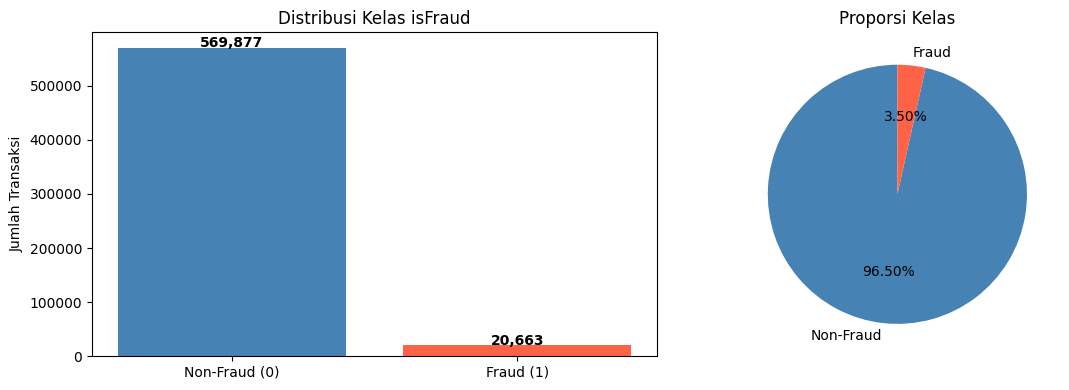

Class imbalance sangat tinggi — kelas Fraud hanya ~3.5%


In [10]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['isFraud'].value_counts()
axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], counts.values, color=['steelblue','tomato'])
axes[0].set_title('Distribusi Kelas isFraud')
axes[0].set_ylabel('Jumlah Transaksi')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Non-Fraud','Fraud'],
            autopct='%1.2f%%', colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Class imbalance sangat tinggi — kelas Fraud hanya ~3.5%')

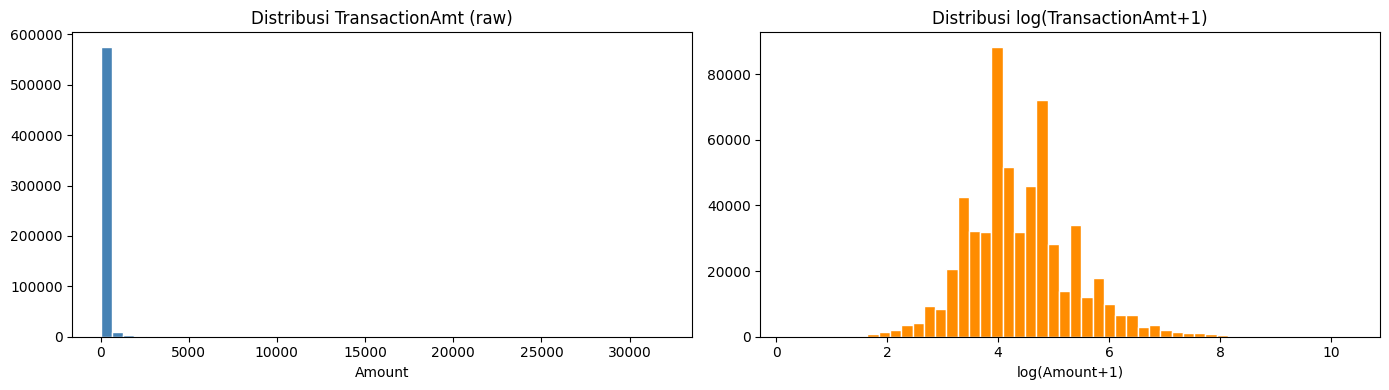

In [11]:
# Distribusi TransactionAmt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['TransactionAmt'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi TransactionAmt (raw)')
axes[0].set_xlabel('Amount')

axes[1].hist(np.log1p(df['TransactionAmt']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi log(TransactionAmt+1)')
axes[1].set_xlabel('log(Amount+1)')

plt.tight_layout()
plt.savefig('transaction_amt_dist.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# Rata-rata amount: fraud vs non-fraud
print('=== Rata-rata TransactionAmt ===')
print(df.groupby('isFraud')['TransactionAmt'].describe())

=== Rata-rata TransactionAmt ===
            count  mean     std       min       25%   50%    75%      max
isFraud                                                                  
0        569877.0   NaN    0.00  0.250977  43.96875  68.5  120.0  31936.0
1         20663.0   inf  232.25  0.291992  35.03125  75.0  161.0   5192.0


## 🛠️ 4. Data Preprocessing & Feature Engineering

In [13]:
# ============================================================
# 4.1 Pisahkan fitur dan target
# ============================================================
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT']  # ID & timestamp tidak informatif sebagai fitur

df_clean = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f'Ukuran X: {X.shape}')
print(f'Ukuran y: {y.shape}')

Ukuran X: (590540, 391)
Ukuran y: (590540,)


In [14]:
# ============================================================
# 4.2 Feature Engineering
# ============================================================

# Log transform pada TransactionAmt (reduce skewness)
if 'TransactionAmt' in X.columns:
    X['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
    print('✅ Ditambahkan: TransactionAmt_log')

# Ekstrak jam dari TransactionDT jika masih ada
if 'TransactionDT' in df.columns:
    X['TransactionHour'] = (df['TransactionDT'] / 3600).astype(int) % 24
    X['TransactionDay']  = (df['TransactionDT'] / (3600 * 24)).astype(int) % 7
    print('✅ Ditambahkan: TransactionHour, TransactionDay')

print(f'\nShape setelah feature engineering: {X.shape}')

✅ Ditambahkan: TransactionAmt_log
✅ Ditambahkan: TransactionHour, TransactionDay

Shape setelah feature engineering: (590540, 394)


In [15]:
# ============================================================
# 4.3 Handle kolom kategorikal → Label Encoding
# ============================================================
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom kategorikal ({len(cat_cols)}): {cat_cols[:10]} ...')

le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].fillna('MISSING')
    X[col] = le.fit_transform(X[col].astype(str))

print('✅ Label Encoding selesai')

Kolom kategorikal (14): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5'] ...
✅ Label Encoding selesai


In [16]:
# ============================================================
# 4.4 Drop kolom dengan missing > 80%
# ============================================================
threshold = 0.8
missing_ratio = X.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
X = X.drop(columns=cols_to_drop)
print(f'✅ Drop {len(cols_to_drop)} kolom (missing > 80%)')
print(f'Shape sekarang: {X.shape}')

✅ Drop 55 kolom (missing > 80%)
Shape sekarang: (590540, 339)


In [17]:
from sklearn.impute import SimpleImputer

# ============================================================
# 4.5 Impute missing values (median untuk numerik)
# ============================================================
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)
print(f'✅ Imputation selesai. Missing values tersisa: {X.isnull().sum().sum()}')

✅ Imputation selesai. Missing values tersisa: 0


In [18]:
from sklearn.model_selection import train_test_split

# ============================================================
# 4.6 Train-Test Split (stratified karena imbalanced)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Fraud rate train: {y_train.mean()*100:.2f}%')
print(f'Fraud rate test : {y_test.mean()*100:.2f}%')

Train: (472432, 339), Test: (118108, 339)
Fraud rate train: 3.50%
Fraud rate test : 3.50%


## 🤖 5. Model Training — Baseline Models

In [19]:
# ============================================================
# Setup MLflow experiment
# ============================================================
mlflow.set_experiment('fraud_detection_UTS')

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train, evaluate, dan log model ke MLflow."""
    with mlflow.start_run(run_name=model_name):
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

        # Metrics
        acc  = accuracy_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_proba)

        # Log ke MLflow
        mlflow.log_param('model_name', model_name)
        mlflow.log_metrics({
            'accuracy': acc, 'f1_score': f1,
            'precision': prec, 'recall': rec, 'roc_auc': auc
        })
        mlflow.sklearn.log_model(model, model_name)

        print(f'\n📊 {model_name}')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  F1-Score  : {f1:.4f}')
        print(f'  Precision : {prec:.4f}')
        print(f'  Recall    : {rec:.4f}')
        print(f'  ROC-AUC   : {auc:.4f}')

        return {
            'Model': model_name, 'Accuracy': acc, 'F1': f1,
            'Precision': prec, 'Recall': rec, 'ROC_AUC': auc
        }

print('✅ Fungsi evaluasi & MLflow siap!')

2026/05/15 01:45:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 01:45:25 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 01:45:28 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_UTS' does not exist. Creating a new experiment.


✅ Fungsi evaluasi & MLflow siap!


In [20]:
# ============================================================
# Train 5 baseline models
# ============================================================
results = []

# 1. Logistic Regression
lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
results.append(evaluate_model(lr, X_train, X_test, y_train, y_test, 'Logistic_Regression'))

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision_Tree'))

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random_Forest'))

# 4. XGBoost
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    scale_pos_weight=fraud_ratio, use_label_encoder=False,
    eval_metric='auc', random_state=42, n_jobs=-1
)
results.append(evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost'))

# 5. LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    class_weight='balanced', random_state=42, n_jobs=-1
)
results.append(evaluate_model(lgb_model, X_train, X_test, y_train, y_test, 'LightGBM'))

print('\n✅ Semua baseline model selesai ditraining!')

2026/05/15 01:47:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 01:47:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Logistic_Regression
  Accuracy  : 0.7792
  F1-Score  : 0.1789
  Precision : 0.1028
  Recall    : 0.6872
  ROC-AUC   : 0.7936


2026/05/15 01:48:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 01:48:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Decision_Tree
  Accuracy  : 0.8367
  F1-Score  : 0.2413
  Precision : 0.1441
  Recall    : 0.7423
  ROC-AUC   : 0.8549


2026/05/15 01:51:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 01:51:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Random_Forest
  Accuracy  : 0.9784
  F1-Score  : 0.5701
  Precision : 0.9374
  Recall    : 0.4096
  ROC-AUC   : 0.9317


2026/05/15 01:53:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 01:53:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 XGBoost
  Accuracy  : 0.8868
  F1-Score  : 0.3325
  Precision : 0.2095
  Recall    : 0.8052
  ROC-AUC   : 0.9220
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.936798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 29861
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


2026/05/15 01:54:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 01:54:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 LightGBM
  Accuracy  : 0.8828
  F1-Score  : 0.3245
  Precision : 0.2032
  Recall    : 0.8043
  ROC-AUC   : 0.9199

✅ Semua baseline model selesai ditraining!


## ⚡ 6. Hyperparameter Tuning dengan Optuna

In [21]:
# ============================================================
# Optuna — Tuning XGBoost (model terbaik dari baseline)
# ============================================================

def objective_xgb(trial):
    """Objective function untuk Optuna — maximize ROC-AUC."""
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight' : fraud_ratio,
        'eval_metric'      : 'auc',
        'use_label_encoder': False,
        'random_state'     : 42,
        'n_jobs'           : -1,
    }
    model = xgb.XGBClassifier(**params)

    # 3-fold CV untuk efisiensi
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()


print('🔍 Memulai Optuna hyperparameter search untuk XGBoost...')
print('   (n_trials=30 — bisa dinaikkan untuk hasil lebih baik)\n')

study_xgb = optuna.create_study(direction='maximize',
                                 study_name='XGBoost_FraudDetection')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f'\n✅ Optuna selesai!')
print(f'Best ROC-AUC (CV): {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

🔍 Memulai Optuna hyperparameter search untuk XGBoost...
   (n_trials=30 — bisa dinaikkan untuk hasil lebih baik)



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optuna selesai!
Best ROC-AUC (CV): 0.9564
Best params: {'n_estimators': 493, 'max_depth': 10, 'learning_rate': 0.06735288682949278, 'subsample': 0.7366313316875455, 'colsample_bytree': 0.6519112721667806, 'min_child_weight': 10, 'gamma': 1.7236611095842576, 'reg_alpha': 6.243140247914037, 'reg_lambda': 0.0009641223477052388}


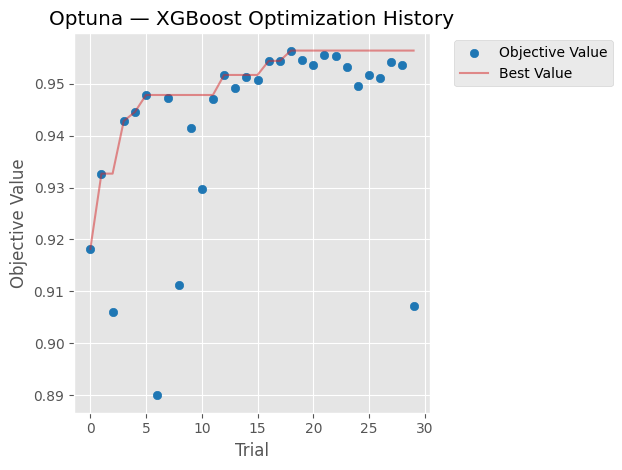

In [22]:
# Visualisasi Optuna optimization history
fig = optuna.visualization.matplotlib.plot_optimization_history(study_xgb)
plt.title('Optuna — XGBoost Optimization History')
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=100, bbox_inches='tight')
plt.show()

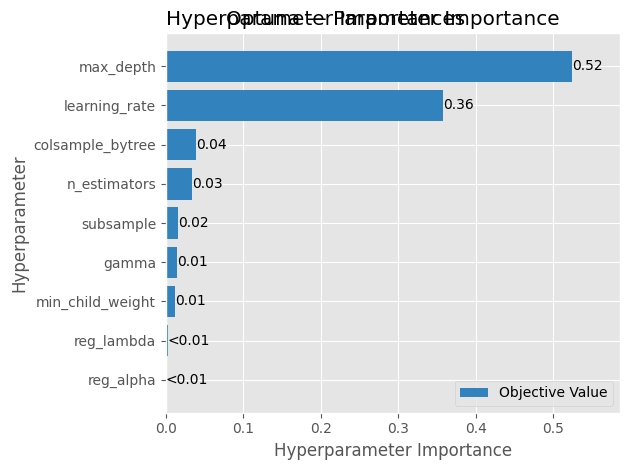

In [23]:
# Visualisasi feature importance dari Optuna
fig2 = optuna.visualization.matplotlib.plot_param_importances(study_xgb)
plt.title('Optuna — Parameter Importance')
plt.tight_layout()
plt.savefig('optuna_param_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
# ============================================================
# Train XGBoost dengan best params & log ke MLflow
# ============================================================
best_params = study_xgb.best_params
best_params.update({
    'scale_pos_weight': fraud_ratio,
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'random_state': 42,
    'n_jobs': -1
})

xgb_tuned = xgb.XGBClassifier(**best_params)
result_tuned = evaluate_model(
    xgb_tuned, X_train, X_test, y_train, y_test,
    'XGBoost_Optuna_Tuned'
)
results.append(result_tuned)

print('\n✅ Model tuned berhasil di-log ke MLflow!')

2026/05/15 04:39:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 04:39:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 XGBoost_Optuna_Tuned
  Accuracy  : 0.9728
  F1-Score  : 0.6712
  Precision : 0.5813
  Recall    : 0.7939
  ROC-AUC   : 0.9666

✅ Model tuned berhasil di-log ke MLflow!


In [25]:
# ============================================================
# Optuna — Tuning LightGBM juga
# ============================================================

def objective_lgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 150),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight'    : 'balanced',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbosity'       : -1,
    }
    model = lgb.LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print('🔍 Optuna tuning LightGBM...')
study_lgb = optuna.create_study(direction='maximize',
                                 study_name='LightGBM_FraudDetection')
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

print(f'\n✅ LightGBM Optuna selesai!')
print(f'Best ROC-AUC (CV): {study_lgb.best_value:.4f}')

lgb_tuned = lgb.LGBMClassifier(**study_lgb.best_params,
                                class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1)
result_lgb_tuned = evaluate_model(
    lgb_tuned, X_train, X_test, y_train, y_test,
    'LightGBM_Optuna_Tuned'
)
results.append(result_lgb_tuned)

🔍 Optuna tuning LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ LightGBM Optuna selesai!
Best ROC-AUC (CV): 0.9556


2026/05/15 06:51:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 06:51:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 LightGBM_Optuna_Tuned
  Accuracy  : 0.9724
  F1-Score  : 0.6696
  Precision : 0.5769
  Recall    : 0.7980
  ROC-AUC   : 0.9670


## 📊 7. Evaluasi & Perbandingan Semua Model

In [26]:
# ============================================================
# Tabel perbandingan semua model
# ============================================================
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

print('=== 🏆 Perbandingan Semua Model ===')
print(df_results.to_string(index=False))

=== 🏆 Perbandingan Semua Model ===
                Model  Accuracy       F1  Precision   Recall  ROC_AUC
LightGBM_Optuna_Tuned  0.972449 0.669645   0.576876 0.797968 0.966962
 XGBoost_Optuna_Tuned  0.972779 0.671167   0.581325 0.793854 0.966595
        Random_Forest  0.978384 0.570130   0.937431 0.409630 0.931657
              XGBoost  0.886841 0.332451   0.209466 0.805226 0.921991
             LightGBM  0.882819 0.324483   0.203241 0.804258 0.919940
        Decision_Tree  0.836683 0.241337   0.144092 0.742318 0.854927
  Logistic_Regression  0.779244 0.178881   0.102824 0.687152 0.793568


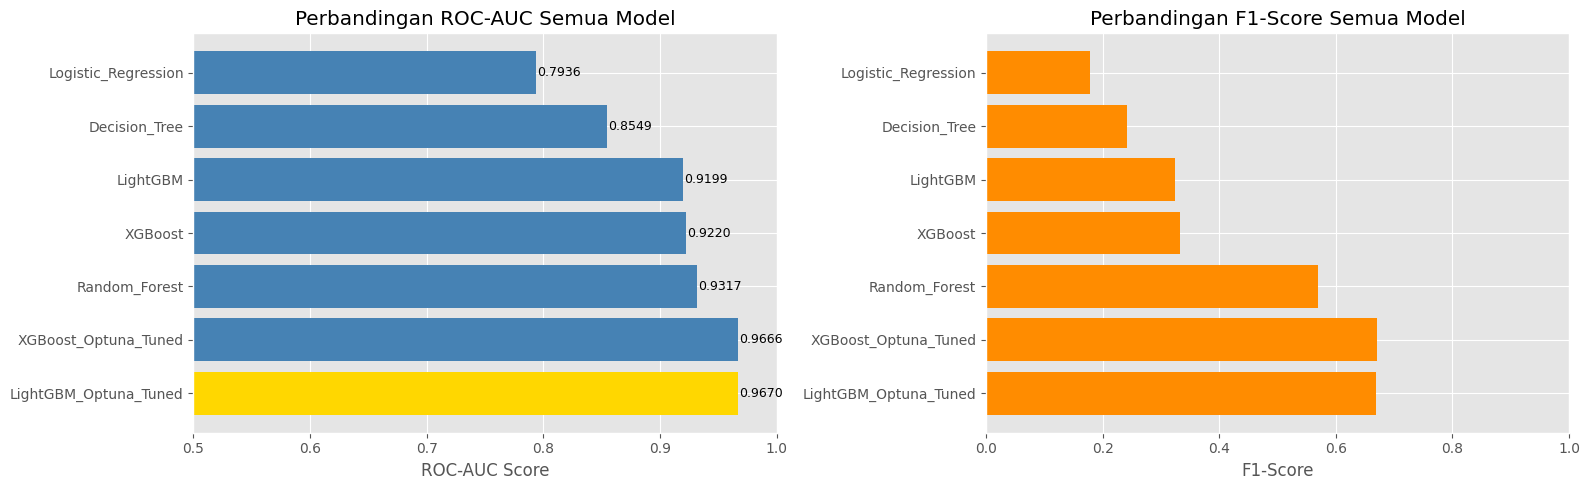

In [27]:
# Visualisasi perbandingan ROC-AUC
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart ROC-AUC
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(df_results))]
bars = axes[0].barh(df_results['Model'], df_results['ROC_AUC'], color=colors)
axes[0].set_xlabel('ROC-AUC Score')
axes[0].set_title('Perbandingan ROC-AUC Semua Model')
axes[0].set_xlim(0.5, 1.0)
for bar, val in zip(bars, df_results['ROC_AUC']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Bar chart F1-Score
axes[1].barh(df_results['Model'], df_results['F1'], color='darkorange')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Perbandingan F1-Score Semua Model')
axes[1].set_xlim(0, 1.0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Best model: LightGBM_Optuna_Tuned


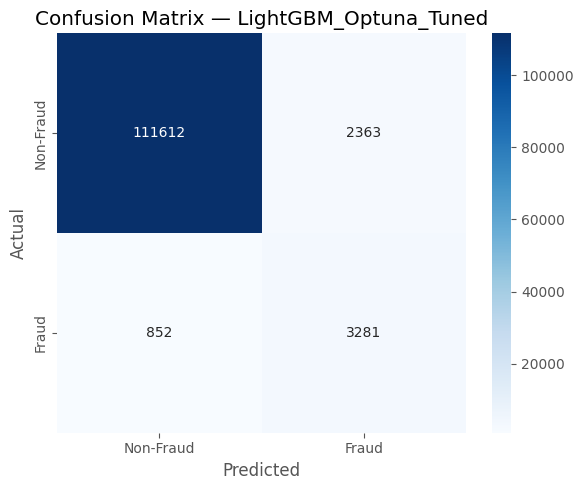


=== Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.98      0.99    113975
       Fraud       0.58      0.79      0.67      4133

    accuracy                           0.97    118108
   macro avg       0.79      0.89      0.83    118108
weighted avg       0.98      0.97      0.97    118108



In [28]:
# ============================================================
# Confusion Matrix — Best Model
# ============================================================
best_model_name = df_results.iloc[0]['Model']
print(f'Best model: {best_model_name}')

# Gunakan xgb_tuned sebagai best model (ganti jika berbeda)
best_model = xgb_tuned
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Fraud','Fraud'],
            yticklabels=['Non-Fraud','Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Non-Fraud','Fraud']))

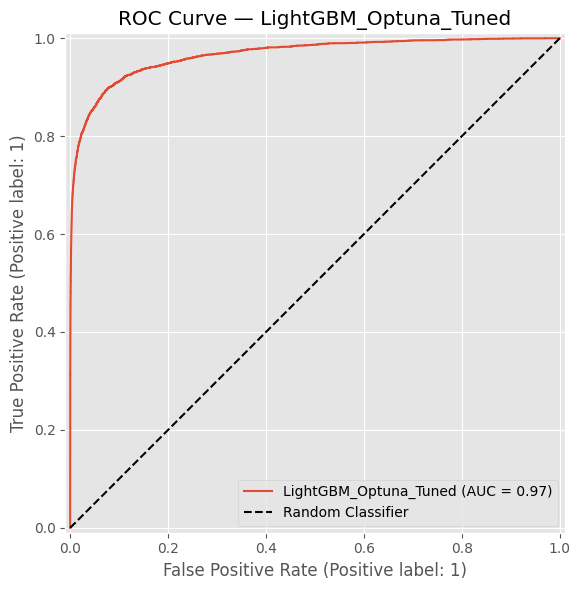

In [29]:
# ============================================================
# ROC Curve — Best Model
# ============================================================
y_proba_best = best_model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_best,
                                  name=best_model_name, ax=ax)
ax.plot([0,1],[0,1],'k--', label='Random Classifier')
ax.set_title(f'ROC Curve — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

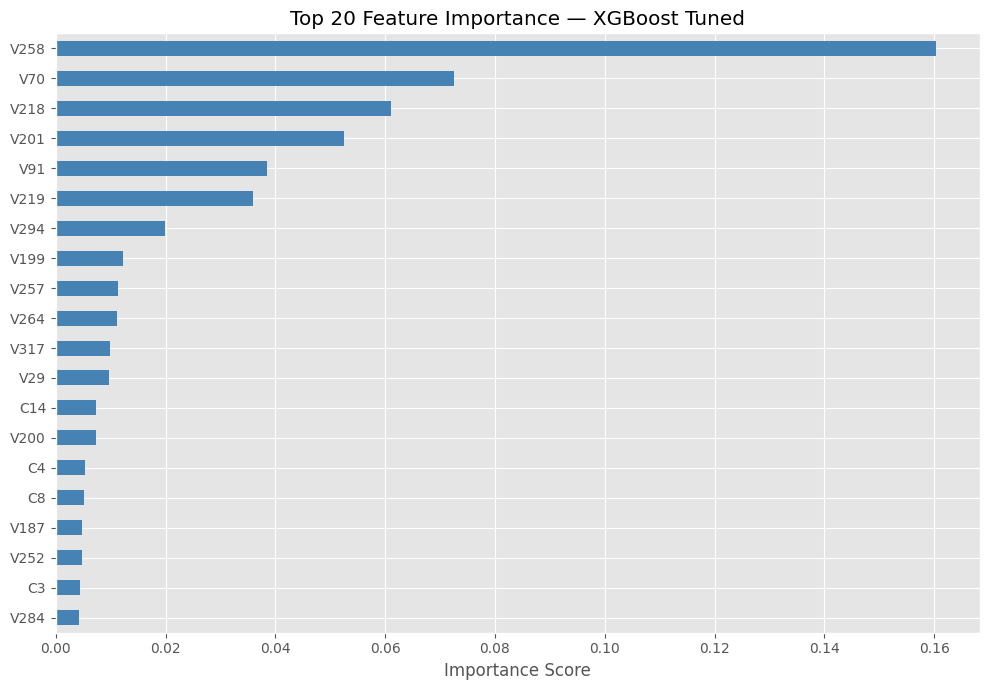

In [30]:
# ============================================================
# Feature Importance — XGBoost Tuned
# ============================================================
feat_imp = pd.Series(
    xgb_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Feature Importance — XGBoost Tuned')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 📝 8. Kesimpulan & Analisis

In [31]:
print('=' * 60)
print('📋 KESIMPULAN EKSPERIMEN')
print('=' * 60)

best_row = df_results.iloc[0]
print(f"""
Dataset      : IEEE-CIS Fraud Detection
Task         : Binary Classification (isFraud)
Metrik Utama : ROC-AUC (karena class imbalance ~3.5%)

Preprocessing yang Dilakukan:
  - Drop kolom dengan missing > 80%
  - Label Encoding untuk fitur kategorikal
  - Median Imputation untuk nilai yang hilang
  - Log transform pada TransactionAmt
  - Feature Engineering: TransactionHour, TransactionDay

Model yang Diuji  : 5 baseline + 2 tuned
Tuning Tool       : Optuna (30 trials per model)
Experiment Log    : MLflow

🏆 Best Model     : {best_row['Model']}
   ROC-AUC        : {best_row['ROC_AUC']:.4f}
   F1-Score       : {best_row['F1']:.4f}
   Precision      : {best_row['Precision']:.4f}
   Recall         : {best_row['Recall']:.4f}
   Accuracy       : {best_row['Accuracy']:.4f}

Insight:
  - Class imbalance sangat signifikan, sehingga accuracy bukan
    metrik yang tepat → ROC-AUC dan F1 lebih relevan
  - Boosting models (XGBoost, LightGBM) jauh lebih baik dari
    Logistic Regression pada data tabular yang kompleks ini
  - Optuna berhasil meningkatkan performa dibanding baseline
  - Fitur paling penting cenderung berkaitan dengan amount
    dan V-features (hasil PCA dari Vesta)
""")
print('=' * 60)

📋 KESIMPULAN EKSPERIMEN

Dataset      : IEEE-CIS Fraud Detection
Task         : Binary Classification (isFraud)
Metrik Utama : ROC-AUC (karena class imbalance ~3.5%)

Preprocessing yang Dilakukan:
  - Drop kolom dengan missing > 80%
  - Label Encoding untuk fitur kategorikal
  - Median Imputation untuk nilai yang hilang
  - Log transform pada TransactionAmt
  - Feature Engineering: TransactionHour, TransactionDay

Model yang Diuji  : 5 baseline + 2 tuned
Tuning Tool       : Optuna (30 trials per model)
Experiment Log    : MLflow

🏆 Best Model     : LightGBM_Optuna_Tuned
   ROC-AUC        : 0.9670
   F1-Score       : 0.6696
   Precision      : 0.5769
   Recall         : 0.7980
   Accuracy       : 0.9724

Insight:
  - Class imbalance sangat signifikan, sehingga accuracy bukan
    metrik yang tepat → ROC-AUC dan F1 lebih relevan
  - Boosting models (XGBoost, LightGBM) jauh lebih baik dari
    Logistic Regression pada data tabular yang kompleks ini
  - Optuna berhasil meningkatkan performa

In [32]:
# ============================================================
# Simpan tabel hasil ke CSV
# ============================================================
df_results.to_csv('model_results.csv', index=False)
print('✅ Hasil disimpan ke model_results.csv')
print('\n📊 Semua eksperimen tersimpan di MLflow.')
print('   Jalankan: mlflow ui  (di terminal) untuk melihat dashboard.')

✅ Hasil disimpan ke model_results.csv

📊 Semua eksperimen tersimpan di MLflow.
   Jalankan: mlflow ui  (di terminal) untuk melihat dashboard.
